<a href="https://colab.research.google.com/github/Alejandra300905/DeepLearning/blob/main/C2_W1_02_Regularizacion_SOL_aplicar_dataset_real_BreastCancer_AlejandraBustos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Curso 2, Semana 1 — Regularización L2 y Dropout

En esta práctica se conserva la nomenclatura de la red profunda anterior: ejemplos por columnas, parámetros `W1`, `b1`, ..., cachés por capa, ReLU en las capas ocultas y sigmoide en la salida.

## Objetivos

1. Reconocer el sobreajuste mediante la brecha entrenamiento–validación.
2. Implementar regularización L2 en el costo y en los gradientes.
3. Implementar dropout invertido en propagación hacia adelante y hacia atrás.
4. Transferir el procedimiento a otro conjunto de datos y otra arquitectura.

> Una regularización adecuada puede reducir la exactitud de entrenamiento y, al mismo tiempo, mejorar la generalización.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split

SEED = 42
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})


## Ejercicio 1. Comparación controlada con `make_moons`

Se utilizará una red deliberadamente amplia y pocos ejemplos de entrenamiento para hacer visible el sobreajuste. Los conjuntos de validación y prueba no participan en el aprendizaje de los parámetros.


train: (2, 270) dev: (2, 315) test: (2, 315)


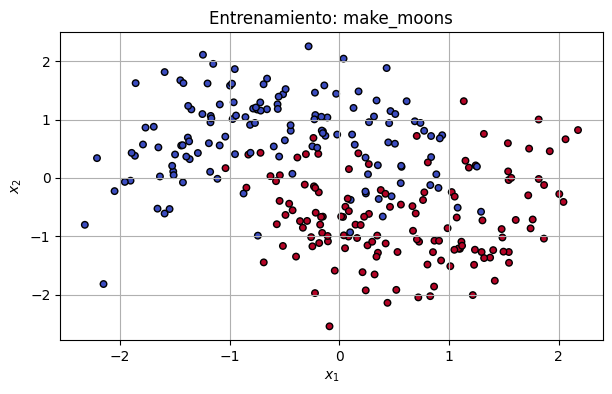

In [ ]:
def prepare_data(X_raw, y_raw, train_size=0.30, seed=SEED):
    X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
        X_raw, y_raw, train_size=train_size, stratify=y_raw, random_state=seed
    )
    X_dev_raw, X_test_raw, y_dev_raw, y_test_raw = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=seed
    )

    # La normalización se calcula únicamente con entrenamiento.
    mu = X_train_raw.mean(axis=0, keepdims=True)
    sigma = X_train_raw.std(axis=0, keepdims=True)

    def transform(X, y):
        return ((X - mu) / sigma).T, y.reshape(1, -1)

    return (*transform(X_train_raw, y_train_raw),
            *transform(X_dev_raw, y_dev_raw),
            *transform(X_test_raw, y_test_raw))


X_raw, y_raw = make_moons(n_samples=900, noise=0.32, random_state=SEED)
X_train, Y_train, X_dev, Y_dev, X_test, Y_test = prepare_data(X_raw, y_raw)

print("train:", X_train.shape, "dev:", X_dev.shape, "test:", X_test.shape)
plt.scatter(X_train[0], X_train[1], c=Y_train.ravel(),
            cmap="coolwarm", edgecolor="k", s=22)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Entrenamiento: make_moons")
plt.show()


### Regularización L2

L2 modifica el objetivo y el gradiente:

$$J_{L2}=J_{datos}+\frac{\lambda}{2m}\sum_{l=1}^{L}\|W^{[l]}\|_F^2,$$

$$dW^{[l]}=dW_{backprop}^{[l]}+\frac{\lambda}{m}W^{[l]}.$$

No se regularizan los sesgos.

### Dropout invertido

En cada capa oculta:

$$D^{[l]}\sim\operatorname{Bernoulli}(keep\_prob),$$

$$\widetilde A^{[l]}=\frac{A^{[l]}\odot D^{[l]}}{keep\_prob}.$$

En el backward se reutiliza exactamente la misma máscara. Dropout se desactiva durante validación, prueba y predicción.


In [ ]:
def sigmoid(Z):
    Z = np.clip(Z, -500, 500)
    return 1 / (1 + np.exp(-Z))


def binary_cross_entropy(AL, Y):
    AL = np.clip(AL, 1e-12, 1 - 1e-12)
    return float(-np.mean(Y * np.log(AL) + (1 - Y) * np.log(1 - AL)))


def initialize_he(layer_dims, seed=SEED):
    rng = np.random.default_rng(seed)
    params = {}
    for l in range(1, len(layer_dims)):
        n_out, n_in = layer_dims[l], layer_dims[l - 1]
        params[f"W{l}"] = rng.standard_normal((n_out, n_in)) * np.sqrt(2 / n_in)
        params[f"b{l}"] = np.zeros((n_out, 1))
    return params


## Implementación de L2 y dropout


In [ ]:
def l2_penalty(params, m, lambd):
    weights = (value for key, value in params.items() if key.startswith("W"))
    return lambd * sum(np.sum(W**2) for W in weights) / (2 * m)


def L_model_forward(X, params, keep_prob=1.0, training=False, rng=None):
    if not 0 < keep_prob <= 1:
        raise ValueError("keep_prob debe pertenecer a (0, 1]")
    if rng is None:
        rng = np.random.default_rng(SEED)

    A, caches = X, []
    L = len(params) // 2

    for l in range(1, L):
        A_prev = A
        W, b = params[f"W{l}"], params[f"b{l}"]
        Z = W @ A_prev + b
        A = np.maximum(0, Z)

        D = None
        if training and keep_prob < 1:
            D = rng.random(A.shape) < keep_prob
            A = A * D / keep_prob

        caches.append({"A_prev": A_prev, "W": W, "Z": Z, "D": D})

    A_prev = A
    W, b = params[f"W{L}"], params[f"b{L}"]
    Z = W @ A_prev + b
    AL = sigmoid(Z)
    caches.append({"A_prev": A_prev, "W": W, "Z": Z, "D": None})
    return AL, caches


def L_model_backward(AL, Y, caches, lambd=0.0, keep_prob=1.0):
    grads = {}
    m, L = Y.shape[1], len(caches)

    cache = caches[-1]
    dZ = AL - Y

    grads[f"dW{L}"] = (dZ @ cache["A_prev"].T / m
                        + lambd * cache["W"] / m)
    grads[f"db{L}"] = np.sum(dZ, axis=1, keepdims=True) / m
    dA = cache["W"].T @ dZ

    for l in reversed(range(1, L)):
        cache = caches[l - 1]

        if cache["D"] is not None:
            dA = dA * cache["D"] / keep_prob

        dZ = dA * (cache["Z"] > 0)
        grads[f"dW{l}"] = (dZ @ cache["A_prev"].T / m
                            + lambd * cache["W"] / m)
        grads[f"db{l}"] = np.sum(dZ, axis=1, keepdims=True) / m
        dA = cache["W"].T @ dZ

    return grads


In [ ]:
def update_parameters_deep(params, grads, learning_rate):
    L = len(params) // 2
    for l in range(1, L + 1):
        params[f"W{l}"] -= learning_rate * grads[f"dW{l}"]
        params[f"b{l}"] -= learning_rate * grads[f"db{l}"]
    return params


def predict_deep(params, X):
    AL, _ = L_model_forward(X, params, training=False)
    return (AL >= 0.5).astype(int)


def accuracy(params, X, Y):
    return 100 * np.mean(predict_deep(params, X) == Y)


def total_weight_norm(params):
    return np.sqrt(sum(np.sum(value**2)
                       for key, value in params.items()
                       if key.startswith("W")))


def train_regularized(X_train, Y_train, layer_dims, lambd=0.0,
                      keep_prob=1.0, iterations=6500,
                      learning_rate=0.03, seed=SEED):
    params = initialize_he(layer_dims, seed)
    rng = np.random.default_rng(seed)
    history = {"data_loss": [], "objective": []}

    for i in range(iterations):
        AL, caches = L_model_forward(
            X_train, params, keep_prob=keep_prob,
            training=(keep_prob < 1), rng=rng
        )
        data_loss = binary_cross_entropy(AL, Y_train)
        objective = data_loss + l2_penalty(params, Y_train.shape[1], lambd)
        grads = L_model_backward(
            AL, Y_train, caches, lambd=lambd, keep_prob=keep_prob
        )
        params = update_parameters_deep(params, grads, learning_rate)

        if i % 100 == 0:
            history["data_loss"].append(data_loss)
            history["objective"].append(objective)

    return params, history


### Experimento controlado

Solo cambia la técnica de regularización. Se mantienen fijos los datos, la arquitectura, la inicialización, la tasa de aprendizaje y el número de iteraciones.


Sin regularización train= 93.33%  dev= 87.94%  brecha= 5.40 pp  ||W||= 15.02
L2                 train= 90.74%  dev= 90.16%  brecha= 0.58 pp  ||W||=  6.78
Dropout            train= 92.22%  dev= 88.57%  brecha= 3.65 pp  ||W||= 14.20


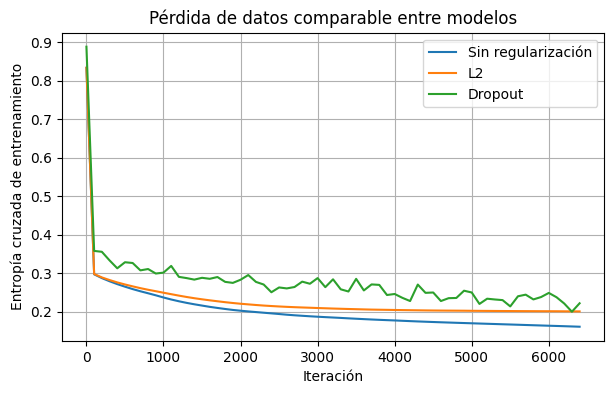

In [ ]:
layer_dims = [2, 60, 40, 20, 1]
settings = {
    "Sin regularización": {"lambd": 0.0, "keep_prob": 1.0},
    "L2":                 {"lambd": 1.5, "keep_prob": 1.0},
    "Dropout":            {"lambd": 0.0, "keep_prob": 0.80},
}

models, histories = {}, {}

for name, cfg in settings.items():
    models[name], histories[name] = train_regularized(
        X_train, Y_train, layer_dims, **cfg
    )

    train_acc = accuracy(models[name], X_train, Y_train)
    dev_acc = accuracy(models[name], X_dev, Y_dev)
    print(f"{name:18s} train={train_acc:6.2f}%  dev={dev_acc:6.2f}%  "
          f"brecha={train_acc-dev_acc:5.2f} pp  "
          f"||W||={total_weight_norm(models[name]):6.2f}")

for name, history in histories.items():
    steps = np.arange(len(history["data_loss"])) * 100
    plt.plot(steps, history["data_loss"], label=name)

plt.xlabel("Iteración")
plt.ylabel("Entropía cruzada de entrenamiento")
plt.title("Pérdida de datos comparable entre modelos")
plt.legend()
plt.show()


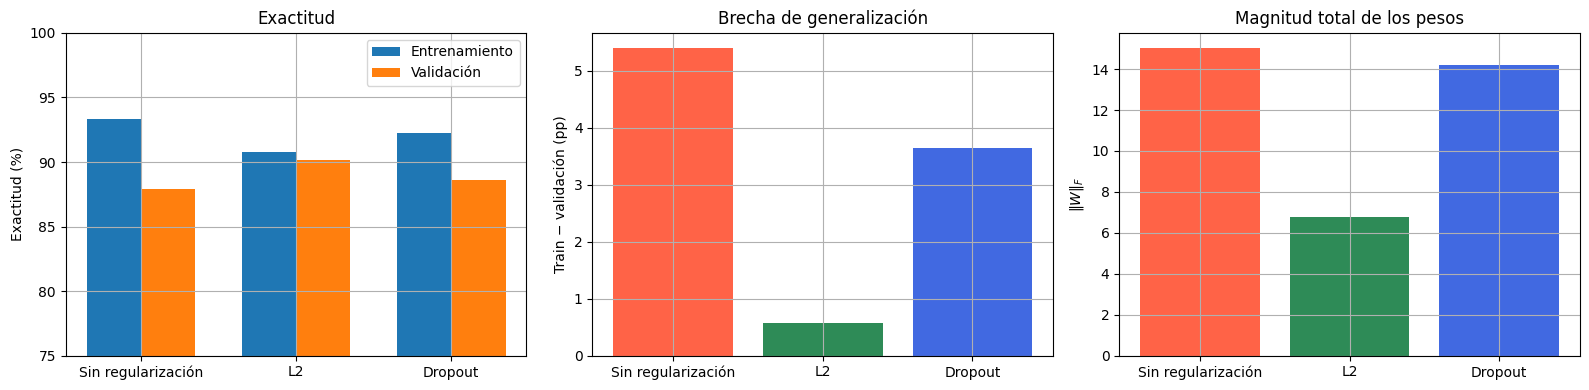

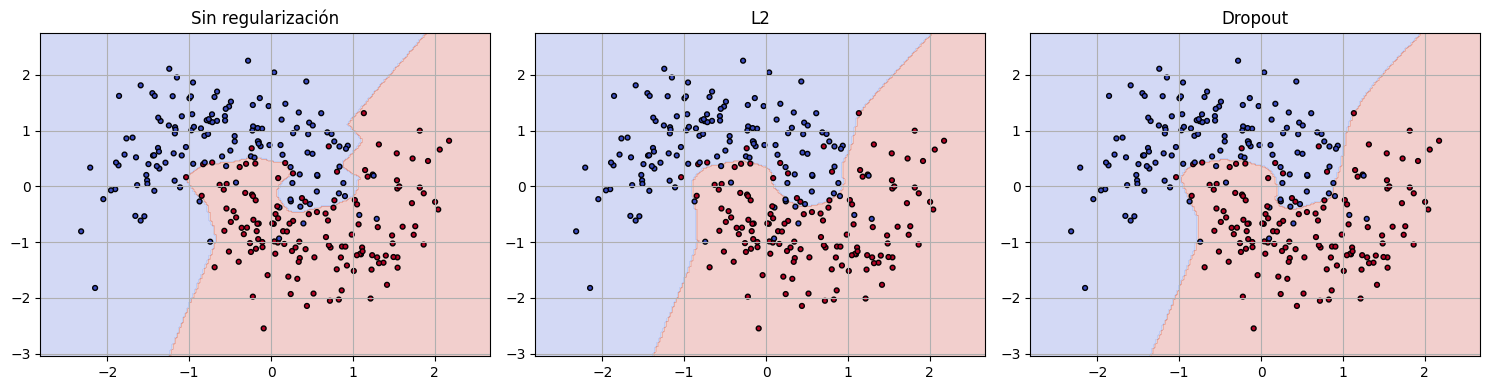

In [ ]:
names = list(models)
train_scores = [accuracy(models[n], X_train, Y_train) for n in names]
dev_scores = [accuracy(models[n], X_dev, Y_dev) for n in names]
gaps = [train_scores[i] - dev_scores[i] for i in range(len(names))]
weight_norms = [total_weight_norm(models[n]) for n in names]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x = np.arange(len(names)); width = 0.35

axes[0].bar(x-width/2, train_scores, width, label="Entrenamiento")
axes[0].bar(x+width/2, dev_scores, width, label="Validación")
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_ylabel("Exactitud (%)"); axes[0].set_ylim(75, 100)
axes[0].set_title("Exactitud"); axes[0].legend()

axes[1].bar(names, gaps, color=["tomato", "seagreen", "royalblue"])
axes[1].set_ylabel("Train − validación (pp)")
axes[1].set_title("Brecha de generalización")

axes[2].bar(names, weight_norms, color=["tomato", "seagreen", "royalblue"])
axes[2].set_ylabel(r"$\Vert W\Vert_F$")
axes[2].set_title("Magnitud total de los pesos")

plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x1 = np.linspace(X_train[0].min()-0.5, X_train[0].max()+0.5, 220)
x2 = np.linspace(X_train[1].min()-0.5, X_train[1].max()+0.5, 220)
xx, yy = np.meshgrid(x1, x2)
grid = np.vstack([xx.ravel(), yy.ravel()])

for ax, (name, params) in zip(axes, models.items()):
    zz = predict_deep(params, grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_train[0], X_train[1], c=Y_train.ravel(),
               cmap="coolwarm", edgecolor="k", s=12)
    ax.set_title(name)

plt.tight_layout(); plt.show()


### Selección y evaluación final

El conjunto de prueba se consulta una sola vez, después de seleccionar el modelo con validación.


In [ ]:
best_name = max(models, key=lambda name: accuracy(models[name], X_dev, Y_dev))
best_model = models[best_name]
print("Modelo seleccionado con validación:", best_name)
print(f"Exactitud final en prueba: {accuracy(best_model, X_test, Y_test):.2f}%")


Modelo seleccionado con validación: L2
Exactitud final en prueba: 88.89%


### Preguntas de análisis

1. ¿Qué evidencia indica que el modelo sin regularización presenta sobreajuste?
2. ¿Por qué L2 reduce la norma $\Vert W\Vert_F$?
3. ¿Por qué dropout se desactiva durante validación y prueba?
4. ¿Por qué una exactitud de entrenamiento menor no implica necesariamente un peor modelo?


## Ejercicio 2. Transferencia a `make_circles`

Ahora se utiliza otro conjunto de datos y una arquitectura diferente. La selección de hiperparámetros debe hacerse con validación; prueba se utiliza únicamente al final.


train: (2, 90) dev: (2, 255) test: (2, 255)


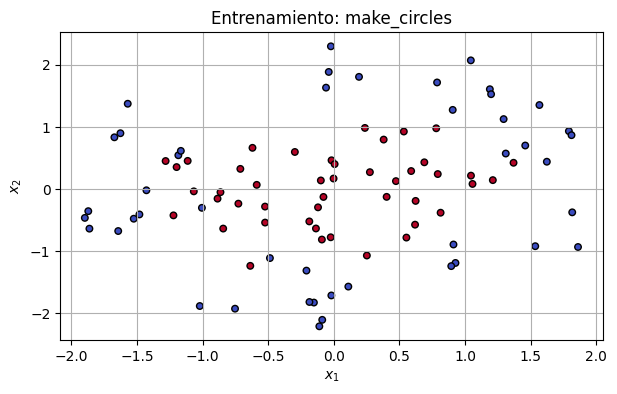

In [ ]:
X_raw, y_raw = make_circles(
    n_samples=600, noise=0.18, factor=0.45, random_state=SEED
)

X_train, Y_train, X_dev, Y_dev, X_test, Y_test = prepare_data(
    X_raw, y_raw, train_size=0.15
)

print("train:", X_train.shape, "dev:", X_dev.shape, "test:", X_test.shape)
plt.scatter(X_train[0], X_train[1], c=Y_train.ravel(),
            cmap="coolwarm", edgecolor="k", s=22)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Entrenamiento: make_circles")
plt.show()


Sin regularización train= 98.89%  dev= 83.92%  brecha=14.97 pp  ||W||= 15.15
L2                 train= 94.44%  dev= 90.20%  brecha= 4.25 pp  ||W||=  4.47
Dropout            train= 96.67%  dev= 85.88%  brecha=10.78 pp  ||W||= 14.24


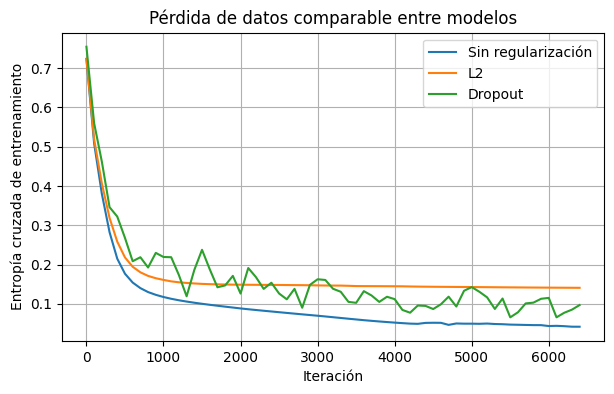

In [ ]:
# Segunda arquitectura: distinta de la utilizada con make_moons.
layer_dims = [2, 64, 32, 16, 1]

# Configuraciones seleccionadas usando únicamente validación.
settings = {
    "Sin regularización": {"lambd": 0.0, "keep_prob": 1.0},
    "L2":                 {"lambd": 1.5, "keep_prob": 1.0},
    "Dropout":            {"lambd": 0.0, "keep_prob": 0.90},
}

models, histories = {}, {}

for name, cfg in settings.items():
    models[name], histories[name] = train_regularized(
        X_train, Y_train, layer_dims, **cfg
    )

    train_acc = accuracy(models[name], X_train, Y_train)
    dev_acc = accuracy(models[name], X_dev, Y_dev)
    print(f"{name:18s} train={train_acc:6.2f}%  dev={dev_acc:6.2f}%  "
          f"brecha={train_acc-dev_acc:5.2f} pp  "
          f"||W||={total_weight_norm(models[name]):6.2f}")

for name, history in histories.items():
    steps = np.arange(len(history["data_loss"])) * 100
    plt.plot(steps, history["data_loss"], label=name)

plt.xlabel("Iteración")
plt.ylabel("Entropía cruzada de entrenamiento")
plt.title("Pérdida de datos comparable entre modelos")
plt.legend()
plt.show()


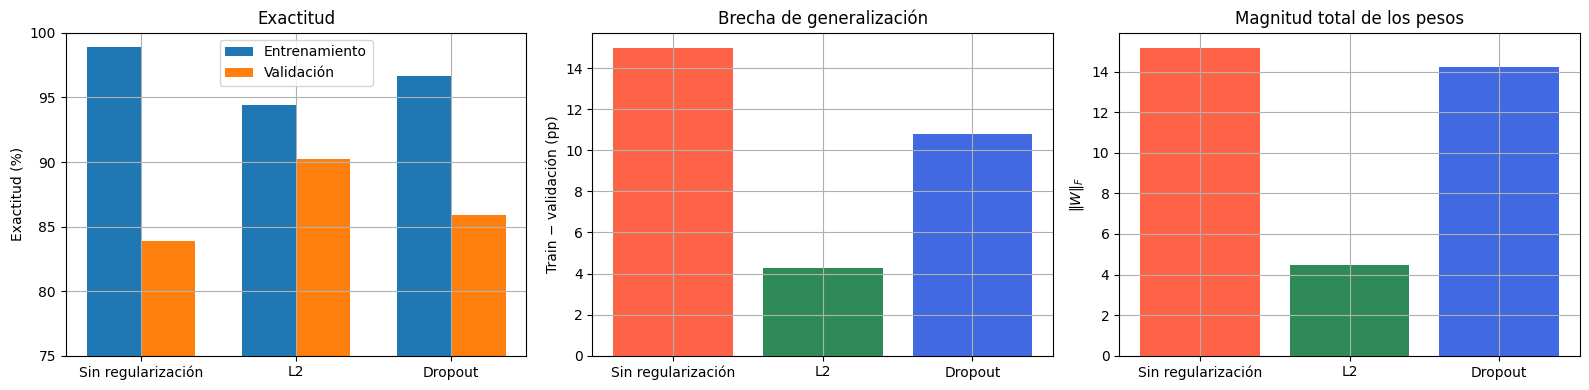

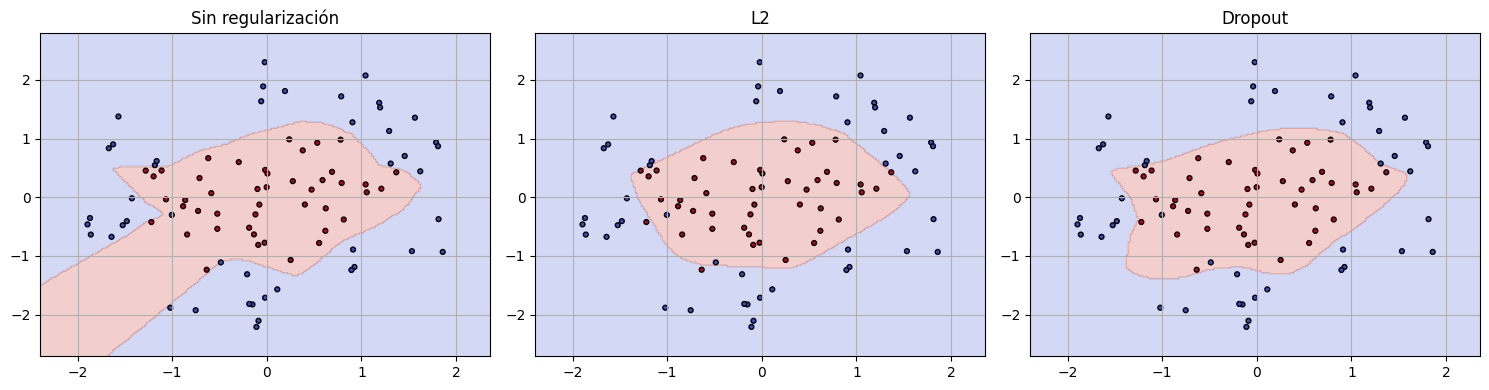

In [ ]:
names = list(models)
train_scores = [accuracy(models[n], X_train, Y_train) for n in names]
dev_scores = [accuracy(models[n], X_dev, Y_dev) for n in names]
gaps = [train_scores[i] - dev_scores[i] for i in range(len(names))]
weight_norms = [total_weight_norm(models[n]) for n in names]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x = np.arange(len(names)); width = 0.35

axes[0].bar(x-width/2, train_scores, width, label="Entrenamiento")
axes[0].bar(x+width/2, dev_scores, width, label="Validación")
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_ylabel("Exactitud (%)"); axes[0].set_ylim(75, 100)
axes[0].set_title("Exactitud"); axes[0].legend()

axes[1].bar(names, gaps, color=["tomato", "seagreen", "royalblue"])
axes[1].set_ylabel("Train − validación (pp)")
axes[1].set_title("Brecha de generalización")

axes[2].bar(names, weight_norms, color=["tomato", "seagreen", "royalblue"])
axes[2].set_ylabel(r"$\Vert W\Vert_F$")
axes[2].set_title("Magnitud total de los pesos")

plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x1 = np.linspace(X_train[0].min()-0.5, X_train[0].max()+0.5, 220)
x2 = np.linspace(X_train[1].min()-0.5, X_train[1].max()+0.5, 220)
xx, yy = np.meshgrid(x1, x2)
grid = np.vstack([xx.ravel(), yy.ravel()])

for ax, (name, params) in zip(axes, models.items()):
    zz = predict_deep(params, grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_train[0], X_train[1], c=Y_train.ravel(),
               cmap="coolwarm", edgecolor="k", s=12)
    ax.set_title(name)

plt.tight_layout(); plt.show()


In [ ]:
best_name = max(models, key=lambda name: accuracy(models[name], X_dev, Y_dev))
best_model = models[best_name]
print("Modelo seleccionado con validación:", best_name)
print(f"Exactitud final en prueba: {accuracy(best_model, X_test, Y_test):.2f}%")


Modelo seleccionado con validación: L2
Exactitud final en prueba: 91.76%


### Conclusiones

- El modelo sin regularización funciona como línea base.
- L2 controla directamente la magnitud de los pesos.
- Dropout entrena subredes distintas y reduce la dependencia entre neuronas.
- El mejor modelo se decide por validación, no por la exactitud de entrenamiento ni por prueba.


# Práctica integral de evaluación: regularización aplicada a un conjunto de datos real para la clasificación binaria.

El propósito principal no es solamente obtener una exactitud elevada, sino construir, identificar y explicar correctamente el **pipeline completo de aprendizaje profundo** que hemos estudiado.

## Conjuntos de datos disponibles

Cada estudiante deberá elegir uno de los siguientes conjuntos de datos:

1. Breast Cancer Wisconsin Diagnostic.
2. Pima Indians Diabetes.
3. Heart Disease.
4. Ionosphere.
5. Sonar Mines vs. Rocks.

Todos corresponden a problemas de clasificación binaria, por lo que se puede utilizar:

- activación sigmoide en la capa de salida;
- entropía cruzada binaria como función de pérdida;
- umbral de clasificación igual a 0.5.

## Opción 1. Breast Cancer Wisconsin Diagnostic

Este conjunto de datos permite clasificar tumores como benignos o malignos mediante características calculadas a partir de imágenes digitalizadas de masas mamarias.

### Características generales

- 569 observaciones.
- 30 variables de entrada.
- Clasificación binaria.
- Variables con escalas diferentes.
- Disponible directamente en `sklearn.datasets`.

La diferencia de escalas entre las variables hace especialmente importante la normalización de los datos.

### Preguntas iniciales

1. ¿Cuál es el significado de cada clase?
2. ¿Las clases están balanceadas?
3. ¿Todas las variables tienen escalas similares?
4. ¿Por qué sería incorrecto entrenar la red sin normalizar?

## Opción 2. Pima Indians Diabetes

Este conjunto de datos busca predecir la presencia o ausencia de diabetes a partir de variables clínicas.

Entre sus variables se encuentran:

- concentración de glucosa;
- presión arterial;
- índice de masa corporal;
- edad;
- número de embarazos;
- grosor de la piel;
- insulina.

### Características generales

- 768 observaciones.
- 8 variables de entrada.
- Clasificación binaria.
- Cierto desbalance entre las clases.
- Posibles valores faltantes representados mediante ceros.

### Consideración importante

Algunos valores iguales a cero pueden no representar una medición real. Por ejemplo, un valor de cero en glucosa, presión arterial o índice de masa corporal puede corresponder a información faltante.

El equipo deberá analizar estos valores y justificar cómo los tratará antes de entrenar la red.

## Opción 3. Heart Disease

Este conjunto de datos busca predecir la presencia de enfermedad cardiaca a partir de información clínica.

Entre sus variables se encuentran:

- edad;
- sexo;
- tipo de dolor torácico;
- presión arterial;
- colesterol;
- frecuencia cardiaca máxima;
- características del electrocardiograma.

### Características generales

- Aproximadamente 303 observaciones.
- 13 variables predictoras principales.
- Variables numéricas y categóricas.
- Posibles valores faltantes.
- Variable objetivo originalmente codificada mediante valores de 0 a 4.

### Conversión a clasificación binaria

Para esta práctica se considerará:

\[
y =
\begin{cases}
0, & \text{ausencia de enfermedad},\\
1, & \text{presencia de enfermedad}.
\end{cases}
\]

Por tanto, los valores originales mayores que cero deberán agruparse como presencia de enfermedad.

### Preguntas iniciales

1. ¿Qué variables son numéricas?
2. ¿Qué variables representan categorías?
3. ¿Existen valores faltantes?
4. ¿Cómo debe transformarse la variable objetivo?

## Opción 4. Ionosphere

Este conjunto de datos contiene mediciones de señales de radar utilizadas para estudiar la ionosfera.

El objetivo es clasificar las señales como:

- buenas: permiten identificar correctamente estructuras en la ionosfera;
- malas: no proporcionan evidencia útil para la detección.

### Características generales

- 351 observaciones.
- 34 variables de entrada.
- Clasificación binaria.
- Muchas variables respecto al número de observaciones.
- Riesgo importante de sobreajuste.

Este conjunto de datos resulta apropiado para observar el efecto de la regularización L2 y dropout.

## Opción 5. Sonar Mines vs. Rocks

Este conjunto de datos contiene señales de sonar reflejadas por diferentes superficies.

El objetivo es clasificar cada señal como:

- mina metálica;
- roca.

### Características generales

- 208 observaciones.
- 60 variables de entrada.
- Clasificación binaria.
- Muy pocas observaciones respecto al número de variables.
- Riesgo elevado de sobreajuste.

Debido a su dimensionalidad y reducido tamaño, este dataset permite analizar claramente la brecha entre entrenamiento y validación.

Cada estudiante seleccionará uno de los datasets reales de clasificación binaria antes sugeridos.

## Actividades

1. Describir el dataset, sus variables, clases, distribución y posibles valores faltantes.
2. Dividir los datos de forma estratificada en entrenamiento, validación y prueba.
3. Calcular la media y desviación estándar únicamente con entrenamiento y utilizarlas para normalizar los tres conjuntos.
4. Comparar al menos tres arquitecturas:

| Arquitectura | Capas |
|---|---|
| Pequeña | `[n_x,16,8,1]` |
| Mediana | `[n_x,64,32,16,1]` |
| Amplia | `[n_x,128,64,32,1]` |

5. Utilizar inicialización He, ReLU en las capas ocultas, sigmoide en la salida y entropía cruzada binaria.
6. Entrenar y comparar:
   - modelo sin regularización;
   - modelo con L2;
   - modelo con dropout.
7. Seleccionar `lambda` y `keep_prob` utilizando únicamente validación.
8. Evaluar una sola vez en prueba el modelo seleccionado.
9. Identificar y explicar en el código:
   - normalización sin fuga de información;
   - inicialización He;
   - penalización L2 en el costo;
   - contribución de L2 en los gradientes;
   - dropout en forward y backward;
   - desactivación de dropout durante validación y prueba.

## Resultados

Presentar una tabla comparativa:

| Arquitectura | Método | Hiperparámetro | Train | Validación | Brecha | $\Vert W\Vert_F$ |
|---|---|---:|---:|---:|---:|---:|
|  | Sin regularización | — |  |  |  |  |
|  | L2 | $\lambda=$ |  |  |  |  |
|  | Dropout | `keep_prob=` |  |  |  |  |

También deberán presentar:

- curvas de pérdida;
- matriz de confusión;
- exactitud, precisión, recall y F1;
- configuración seleccionada y resultado final en prueba.

## Pregunta integradora

> ¿Qué arquitectura y método de regularización ofrecen la mejor capacidad de generalización y qué resultados respaldan esta conclusión?

No será suficiente ejecutar el código. Durante la exposición, el estudiante deberá identificar y explicar cada etapa del pipeline.

### 1. Descripción del dataset
El dataset usado sera el de Breast Cancer Wisconsin Diagnostic.
- 569 observaciones, 30 variables numéricas de entrada calculadas a partir de imágenes digitalizadas de masas mamarias (radio, textura, perímetro, área, suavidad, etc., cada una con su media, error estándar y "peor valor").
- Variable objetivo original de `sklearn`: 0 = maligno, 1 = benigno. **Se invierte la codificación** a `y = 1` para maligno y `y = 0` para benigno, de modo que la clase positiva sea la condición clínicamente relevante a detectar (igual convención que Heart Disease en el enunciado: 1 = presencia de la condición).

In [ ]:
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd
bc = load_breast_cancer()
X_raw_bc = bc.data
y_raw_bc = 1 - bc.target  # 1 = maligno, 0 = benigno (se invierte la codificación original)
n_samples_bc, n_x_bc = X_raw_bc.shape

print(f"Observaciones: {n_samples_bc}   Variables de entrada: {n_x_bc}")
print(f"Clases: {dict(zip(['benigno (0)', 'maligno (1)'], np.bincount(y_raw_bc)))}")
print(f"Valores faltantes (NaN): {np.isnan(X_raw_bc).sum()}")

# Evidencia de las diferencias de escala entre variables (pregunta 3)
idx_area = list(bc.feature_names).index("mean area")
idx_smooth = list(bc.feature_names).index("mean smoothness")
print(f"\n'mean area'      -> min={X_raw_bc[:, idx_area].min():.2f}  max={X_raw_bc[:, idx_area].max():.2f}  "
      f"media={X_raw_bc[:, idx_area].mean():.2f}  std={X_raw_bc[:, idx_area].std():.2f}")
print(f"'mean smoothness' -> min={X_raw_bc[:, idx_smooth].min():.4f}  max={X_raw_bc[:, idx_smooth].max():.4f}  "
      f"media={X_raw_bc[:, idx_smooth].mean():.4f}  std={X_raw_bc[:, idx_smooth].std():.4f}")


Observaciones: 569   Variables de entrada: 30
Clases: {'benigno (0)': np.int64(357), 'maligno (1)': np.int64(212)}
Valores faltantes (NaN): 0

'mean area'      -> min=143.50  max=2501.00  media=654.89  std=351.60
'mean smoothness' -> min=0.0526  max=0.1634  media=0.0964  std=0.0141


### 2. Respuestas a las preguntas iniciales

1. **Significado de cada clase.** `y=1` (maligno): el tumor es canceroso. `y=0` (benigno): el tumor no es canceroso.
2. **¿Las clases están balanceadas?** No perfectamente, pero tampoco de forma extrema: aproximadamente 63 % benignos y 37 % malignos (357 vs. 212). Es suficientemente moderado como para usar exactitud como referencia principal, siempre acompañada de precisión/recall/F1.
3. **¿Todas las variables tienen escalas similares?** No. Como se ve arriba, `mean area` toma valores del orden de cientos–miles, mientras que `mean smoothness` toma valores del orden de centésimas. La diferencia de varios órdenes de magnitud es evidente.
4. **¿Por qué sería incorrecto entrenar sin normalizar?** Con inicialización He y descenso de gradiente, una variable con escala mucho mayor domina las activaciones y los gradientes de la primera capa, haciendo que el aprendizaje dependa casi únicamente de esa variable y que la tasa de aprendizaje óptima para unas variables sea demasiado grande o pequeña para otras. Además, la inicialización He (`sqrt(2/n_in)`) asume implícitamente entradas de varianza comparable entre sí; sin normalizar, esa suposición se rompe y el entrenamiento se vuelve inestable o muy lento.

### 3. Partición y normalización

Se reutiliza el mismo patrón de `prepare_data` ya usado arriba, generalizado a train/dev/test 60 %/20 %/20 %. **La media (`mu`) y la desviación estándar (`sigma`) se calculan únicamente sobre `X_train_raw`**, nunca sobre dev o test — esa es la línea exacta donde se evita la fuga de información (*data leakage*): si `mu`/`sigma` se calcularan sobre el dataset completo, información de dev/test (aunque sea solo su escala) se filtraría hacia el entrenamiento.

In [ ]:
def prepare_data_bc(X_raw, y_raw, train_size=0.60, dev_size=0.20, seed=SEED):
    X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
        X_raw, y_raw, train_size=train_size, stratify=y_raw, random_state=seed
    )
    rel_test = (1 - train_size - dev_size) / (1 - train_size)
    X_dev_raw, X_test_raw, y_dev_raw, y_test_raw = train_test_split(
        X_temp, y_temp, test_size=rel_test, stratify=y_temp, random_state=seed
    )

    # <<< Normalización sin fuga de información: mu y sigma solo de entrenamiento >>>
    mu = X_train_raw.mean(axis=0, keepdims=True)
    sigma = X_train_raw.std(axis=0, keepdims=True)

    def transform(X, y):
        return ((X - mu) / sigma).T, y.reshape(1, -1) #Normalización

    return (*transform(X_train_raw, y_train_raw),
            *transform(X_dev_raw, y_dev_raw),
            *transform(X_test_raw, y_test_raw))


X_train_bc, Y_train_bc, X_dev_bc, Y_dev_bc, X_test_bc, Y_test_bc = prepare_data_bc(X_raw_bc, y_raw_bc)
print("train:", X_train_bc.shape, " dev:", X_dev_bc.shape, " test:", X_test_bc.shape)
print("Proporción de malignos -> train:", Y_train_bc.mean().round(3),
      " dev:", Y_dev_bc.mean().round(3), " test:", Y_test_bc.mean().round(3))

train: (30, 341)  dev: (30, 114)  test: (30, 114)
Proporción de malignos -> train: 0.372  dev: 0.377  test: 0.368


### 4. Métricas de evaluación manuales

Además de `accuracy` (ya definida arriba), se implementan a mano —usando solo NumPy— la matriz de confusión y precisión/recall/F1, tal como pide el enunciado.

In [ ]:
def confusion_matrix_manual(Y_true, Y_pred):
    Y_true = Y_true.ravel(); Y_pred = Y_pred.ravel()
    tp = int(np.sum((Y_true == 1) & (Y_pred == 1)))
    tn = int(np.sum((Y_true == 0) & (Y_pred == 0)))
    fp = int(np.sum((Y_true == 0) & (Y_pred == 1)))
    fn = int(np.sum((Y_true == 1) & (Y_pred == 0)))
    return np.array([[tn, fp], [fn, tp]])  # [[TN, FP], [FN, TP]]


def precision_recall_f1(Y_true, Y_pred):
    cm = confusion_matrix_manual(Y_true, Y_pred)
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

### 5. Arquitecturas a comparar

Las tres arquitecturas pedidas en el enunciado, con `n_x = 30` (número de variables de entrada de este dataset):

In [ ]:
architectures_bc = {
    "Pequeña": [n_x_bc, 16, 8, 1],
    "Mediana": [n_x_bc, 64, 32, 16, 1],
    "Amplia":  [n_x_bc, 128, 64, 32, 1],
}
for name, dims in architectures_bc.items():
    print(f"{name:8s} -> {dims}  ({len(dims) - 2} capas ocultas)")

Pequeña  -> [30, 16, 8, 1]  (2 capas ocultas)
Mediana  -> [30, 64, 32, 16, 1]  (3 capas ocultas)
Amplia   -> [30, 128, 64, 32, 1]  (3 capas ocultas)


### 6. Selección de `lambda` y `keep_prob` usando únicamente el conjunto de validación

Para cada arquitectura se hace una búsqueda pequeña de hiperparámetros: varios valores candidatos de `lambd` (para L2) y de `keep_prob` (para dropout), entrenando con cada uno y **evaluando la exactitud en `X_dev_bc`/`Y_dev_bc`** — nunca en test. Se conserva el valor con mejor exactitud de validación.

In [ ]:
lambda_grid = [0.1, 0.3, 0.7, 1.5]
keep_prob_grid = [0.6, 0.7, 0.8, 0.9]#trabajamos con el porcentaje que aparece aqui y apagamos el resto

all_models_bc = {}
all_histories_bc = {}
search_logs_bc = {}

for arch_name, layer_dims in architectures_bc.items():
    all_models_bc[arch_name] = {}
    all_histories_bc[arch_name] = {}

    # --- Sin regularización (línea base) ---
    base_params, base_hist = train_regularized(X_train_bc, Y_train_bc, layer_dims, lambd=0.0, keep_prob=1.0)
    all_models_bc[arch_name]["Sin regularización"] = base_params
    all_histories_bc[arch_name]["Sin regularización"] = base_hist

    # --- Búsqueda de lambda (L2) por validación ---
    best_lambda, best_lambda_dev, best_lambda_params, best_lambda_hist = None, -1, None, None
    lam_log = []
    for lambd in lambda_grid:
        p, h = train_regularized(X_train_bc, Y_train_bc, layer_dims, lambd=lambd, keep_prob=1.0)
        dev_acc = accuracy(p, X_dev_bc, Y_dev_bc)
        lam_log.append((lambd, dev_acc))
        if dev_acc > best_lambda_dev:
            best_lambda, best_lambda_dev, best_lambda_params, best_lambda_hist = lambd, dev_acc, p, h
    l2_label = f"L2 (λ={best_lambda})"
    all_models_bc[arch_name][l2_label] = best_lambda_params
    all_histories_bc[arch_name][l2_label] = best_lambda_hist

    # --- Búsqueda de keep_prob (dropout) por validación ---
    best_kp, best_kp_dev, best_kp_params, best_kp_hist = None, -1, None, None
    kp_log = []
    for kp in keep_prob_grid:
        p, h = train_regularized(X_train_bc, Y_train_bc, layer_dims, lambd=0.0, keep_prob=kp)
        dev_acc = accuracy(p, X_dev_bc, Y_dev_bc)
        kp_log.append((kp, dev_acc))
        if dev_acc > best_kp_dev:
            best_kp, best_kp_dev, best_kp_params, best_kp_hist = kp, dev_acc, p, h
    dropout_label = f"Dropout (keep_prob={best_kp})"
    all_models_bc[arch_name][dropout_label] = best_kp_params
    all_histories_bc[arch_name][dropout_label] = best_kp_hist

    search_logs_bc[arch_name] = {"lambda_log": lam_log, "keep_prob_log": kp_log,
                                  "best_lambda": best_lambda, "best_keep_prob": best_kp}

    print(f"\n=== {arch_name} {layer_dims} ===")
    print("  Búsqueda λ  (λ, dev%):", [(l, round(a, 2)) for l, a in lam_log], "-> mejor λ =", best_lambda)
    print("  Búsqueda kp (kp, dev%):", [(k, round(a, 2)) for k, a in kp_log], "-> mejor keep_prob =", best_kp)


=== Pequeña [30, 16, 8, 1] ===
  Búsqueda λ  (λ, dev%): [(0.1, np.float64(97.37)), (0.3, np.float64(97.37)), (0.7, np.float64(97.37)), (1.5, np.float64(97.37))] -> mejor λ = 0.1
  Búsqueda kp (kp, dev%): [(0.6, np.float64(96.49)), (0.7, np.float64(97.37)), (0.8, np.float64(97.37)), (0.9, np.float64(97.37))] -> mejor keep_prob = 0.7

=== Mediana [30, 64, 32, 16, 1] ===
  Búsqueda λ  (λ, dev%): [(0.1, np.float64(97.37)), (0.3, np.float64(97.37)), (0.7, np.float64(98.25)), (1.5, np.float64(98.25))] -> mejor λ = 0.7
  Búsqueda kp (kp, dev%): [(0.6, np.float64(98.25)), (0.7, np.float64(98.25)), (0.8, np.float64(98.25)), (0.9, np.float64(98.25))] -> mejor keep_prob = 0.6

=== Amplia [30, 128, 64, 32, 1] ===
  Búsqueda λ  (λ, dev%): [(0.1, np.float64(98.25)), (0.3, np.float64(98.25)), (0.7, np.float64(98.25)), (1.5, np.float64(98.25))] -> mejor λ = 0.1
  Búsqueda kp (kp, dev%): [(0.6, np.float64(98.25)), (0.7, np.float64(98.25)), (0.8, np.float64(98.25)), (0.9, np.float64(98.25))] -> mejor k

### 7. Resultados de entrenamiento (train / validación / brecha / norma de pesos) por arquitectura y técnica

In [ ]:
for arch_name in architectures_bc:
    print(f"\n=== {arch_name} ===")
    for tech, params in all_models_bc[arch_name].items():
        tr = accuracy(params, X_train_bc, Y_train_bc)
        dv = accuracy(params, X_dev_bc, Y_dev_bc)
        print(f"  {tech:28s} train={tr:6.2f}%  dev={dv:6.2f}%  "
              f"brecha={tr - dv:5.2f} pp  ||W||={total_weight_norm(params):6.2f}")


=== Pequeña ===
  Sin regularización           train=100.00%  dev= 97.37%  brecha= 2.63 pp  ||W||=  8.26
  L2 (λ=0.1)                   train=100.00%  dev= 97.37%  brecha= 2.63 pp  ||W||=  7.91
  Dropout (keep_prob=0.7)      train=100.00%  dev= 97.37%  brecha= 2.63 pp  ||W||=  8.25

=== Mediana ===
  Sin regularización           train=100.00%  dev= 97.37%  brecha= 2.63 pp  ||W||= 15.60
  L2 (λ=0.7)                   train=100.00%  dev= 98.25%  brecha= 1.75 pp  ||W||= 10.88
  Dropout (keep_prob=0.6)      train= 99.71%  dev= 98.25%  brecha= 1.46 pp  ||W||= 15.25

=== Amplia ===
  Sin regularización           train=100.00%  dev= 98.25%  brecha= 1.75 pp  ||W||= 21.64
  L2 (λ=0.1)                   train=100.00%  dev= 98.25%  brecha= 1.75 pp  ||W||= 20.48
  Dropout (keep_prob=0.6)      train=100.00%  dev= 98.25%  brecha= 1.75 pp  ||W||= 21.36


### 8. Tabla comparativa

In [ ]:
rows_bc = []
for arch_name in architectures_bc:
    for tech, params in all_models_bc[arch_name].items():
        tr = accuracy(params, X_train_bc, Y_train_bc)
        dv = accuracy(params, X_dev_bc, Y_dev_bc)
        if tech.startswith("L2"):
            metodo, hiperparam = "L2", tech.split("λ=")[1].rstrip(")")
        elif tech.startswith("Dropout"):
            metodo, hiperparam = "Dropout", tech.split("keep_prob=")[1].rstrip(")")
        else:
            metodo, hiperparam = "Sin regularización", "—"
        rows_bc.append((arch_name, metodo, hiperparam, tr, dv, tr - dv, total_weight_norm(params)))

header = f"| {'Arquitectura':10s} | {'Método':18s} | {'Hiperparám.':11s} | {'Train':>6s} | {'Validación':>10s} | {'Brecha':>7s} | {'||W||_F':>8s} |"
print(header)
print("|" + "-" * (len(header) - 2) + "|")
for arch_name, metodo, hp, tr, dv, gap, wn in rows_bc:
    print(f"| {arch_name:10s} | {metodo:18s} | {hp:11s} | {tr:5.2f}% | {dv:9.2f}% | {gap:6.2f}p | {wn:8.2f} |")

| Arquitectura | Método             | Hiperparám. |  Train | Validación |  Brecha |  ||W||_F |
|--------------------------------------------------------------------------------------------|
| Pequeña    | Sin regularización | —           | 100.00% |     97.37% |   2.63p |     8.26 |
| Pequeña    | L2                 | 0.1         | 100.00% |     97.37% |   2.63p |     7.91 |
| Pequeña    | Dropout            | 0.7         | 100.00% |     97.37% |   2.63p |     8.25 |
| Mediana    | Sin regularización | —           | 100.00% |     97.37% |   2.63p |    15.60 |
| Mediana    | L2                 | 0.7         | 100.00% |     98.25% |   1.75p |    10.88 |
| Mediana    | Dropout            | 0.6         | 99.71% |     98.25% |   1.46p |    15.25 |
| Amplia     | Sin regularización | —           | 100.00% |     98.25% |   1.75p |    21.64 |
| Amplia     | L2                 | 0.1         | 100.00% |     98.25% |   1.75p |    20.48 |
| Amplia     | Dropout            | 0.6         | 100.00% |

### 9. Curvas de pérdida por arquitectura

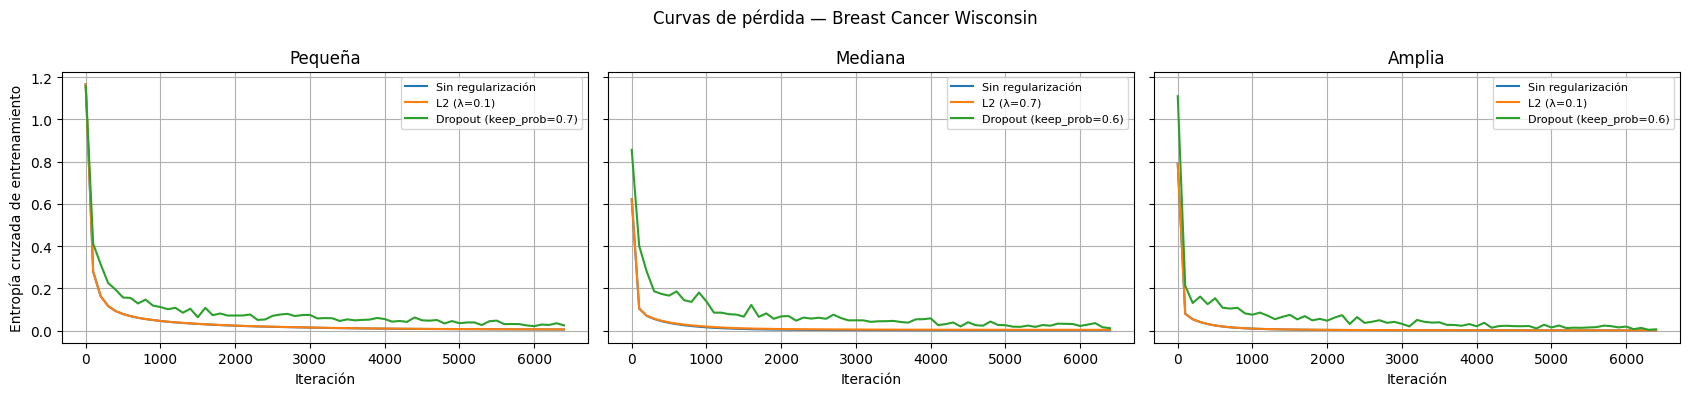

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
for ax, arch_name in zip(axes, architectures_bc):
    for tech, hist in all_histories_bc[arch_name].items():
        steps = np.arange(len(hist["data_loss"])) * 100
        ax.plot(steps, hist["data_loss"], label=tech)
    ax.set_title(arch_name)
    ax.set_xlabel("Iteración")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Entropía cruzada de entrenamiento")
plt.suptitle("Curvas de pérdida — Breast Cancer Wisconsin")
plt.tight_layout()
plt.show()

### 10. Comparación gráfica: exactitud, brecha de generalización y norma de pesos

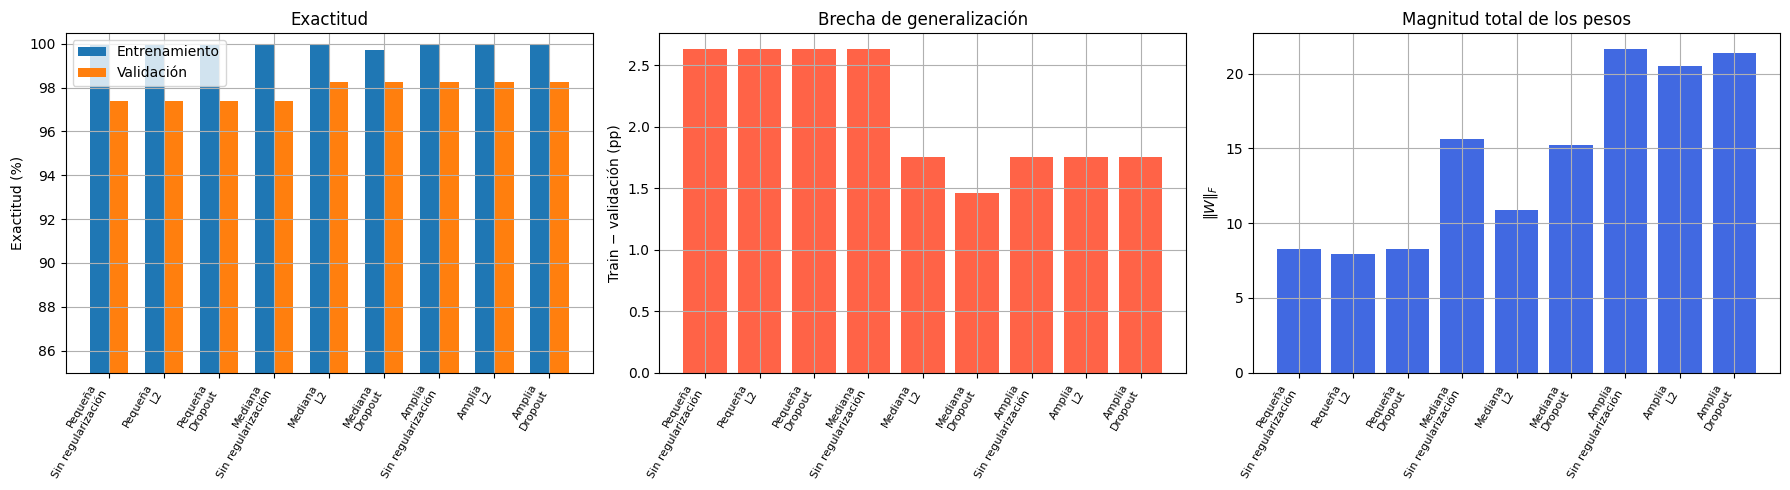

In [ ]:
labels_bc = [f"{a}\n{m}" for a, m, *_ in rows_bc]
train_vals = [r[3] for r in rows_bc]
dev_vals = [r[4] for r in rows_bc]
gap_vals = [r[5] for r in rows_bc]
norm_vals = [r[6] for r in rows_bc]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(labels_bc)); width = 0.35

axes[0].bar(x - width/2, train_vals, width, label="Entrenamiento")
axes[0].bar(x + width/2, dev_vals, width, label="Validación")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_bc, rotation=60, ha="right", fontsize=8)
axes[0].set_ylabel("Exactitud (%)"); axes[0].set_ylim(85, 100.5)
axes[0].set_title("Exactitud"); axes[0].legend()

axes[1].bar(x, gap_vals, color="tomato")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_bc, rotation=60, ha="right", fontsize=8)
axes[1].set_ylabel("Train − validación (pp)")
axes[1].set_title("Brecha de generalización")

axes[2].bar(x, norm_vals, color="royalblue")
axes[2].set_xticks(x); axes[2].set_xticklabels(labels_bc, rotation=60, ha="right", fontsize=8)
axes[2].set_ylabel(r"$\Vert W\Vert_F$")
axes[2].set_title("Magnitud total de los pesos")

plt.tight_layout()
plt.show()

### 11. Selección final por validación y evaluación única en prueba

Se elige, entre las 9 combinaciones (3 arquitecturas × 3 técnicas), la de mayor exactitud de **validación**. El conjunto de prueba se consulta **una sola vez**, después de fijar esa elección — nunca antes.

In [ ]:
best_row_bc = max(rows_bc, key=lambda r: r[4])  # r[4] = exactitud de validación
best_arch_bc, best_metodo_bc, best_hp_bc = best_row_bc[0], best_row_bc[1], best_row_bc[2]
best_tech_label_bc = next(t for t in all_models_bc[best_arch_bc]
                          if (best_metodo_bc == "Sin regularización" and t == "Sin regularización")
                          or (best_metodo_bc != "Sin regularización" and t.startswith(best_metodo_bc)))
best_model_bc = all_models_bc[best_arch_bc][best_tech_label_bc]

print(f"Modelo seleccionado por validación: {best_arch_bc} — {best_tech_label_bc}")
print(f"Exactitud de validación: {best_row_bc[4]:.2f}%")

test_pred_bc = predict_deep(best_model_bc, X_test_bc)
test_acc_bc = accuracy(best_model_bc, X_test_bc, Y_test_bc)
prec_bc, rec_bc, f1_bc = precision_recall_f1(Y_test_bc, test_pred_bc)
cm_bc = confusion_matrix_manual(Y_test_bc, test_pred_bc)

print(f"\nEvaluación única en prueba:")
print(f"  Exactitud : {test_acc_bc:.2f}%")
print(f"  Precisión : {prec_bc:.3f}")
print(f"  Recall    : {rec_bc:.3f}")
print(f"  F1-score  : {f1_bc:.3f}")

Modelo seleccionado por validación: Mediana — L2 (λ=0.7)
Exactitud de validación: 98.25%

Evaluación única en prueba:
  Exactitud : 96.49%
  Precisión : 0.975
  Recall    : 0.929
  F1-score  : 0.951


### 12. Matriz de confusión del modelo final (conjunto de prueba)

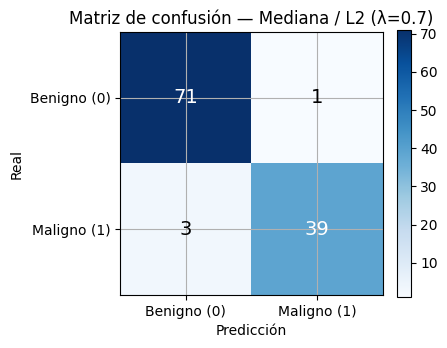

In [ ]:
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm_bc, cmap="Blues")
labels_cm = ["Benigno (0)", "Maligno (1)"]
ax.set_xticks([0, 1]); ax.set_xticklabels(labels_cm)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels_cm)
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión — {best_arch_bc} / {best_tech_label_bc}")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_bc[i, j]), ha="center", va="center",
                color="white" if cm_bc[i, j] > cm_bc.max()/2 else "black", fontsize=14)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()